In [12]:
import numpy as np
import matplotlib.pyplot as plt
import toml
from flups.analysis import ref_spec_wn, nm2ev, nm2cmi, cmi2nm, default_ref_spectra, ref_spec_wn, ref_spec_wl, lognorm, __dirpath
from lmfit.models import LognormalModel, lognormal
from spectro.utils import rescale

In [2]:
%matplotlib inline

In [3]:
??lognormal

Signature: lognormal(x, amplitude=1.0, center=0.0, sigma=1)
Source:   
def lognormal(x, amplitude=1.0, center=0., sigma=1):
    """Return a log-normal function.

    lognormal(x, amplitude, center, sigma) =
        (amplitude/(x*sigma*s2pi)) * exp(-(ln(x) - center)**2/ (2* sigma**2))

    """
    if isinstance(x, (int, float)):
        x = max(tiny, x)
    else:
        x[where(x <= tiny)] = tiny
    return ((amplitude/(x*max(tiny, sigma*s2pi))) *
            exp(-(log(x)-center)**2 / max(tiny, (2*sigma**2))))
File:      c:\users\palatosa\miniconda3\envs\main\lib\site-packages\lmfit\lineshapes.py
Type:      function

In [4]:
default_ref_spectra

{'C6H': [[0.7322, 21218.0, 2871.0, -0.2757],
  [0.3552, 22118.0, 2089.0, -0.1113]],
 'C153': [[0.9333, 18803.0, 3287.0, -0.2771],
  [0.1206, 19589.0, 1339.0, -0.076]],
 'DCM': [[0.229, 15499.0, 2798.0, -0.1687], [0.7641, 15955.0, 2245.0, 0.0298]]}

In [5]:
default_ref_spectra

{'C6H': [[0.7322, 21218.0, 2871.0, -0.2757],
  [0.3552, 22118.0, 2089.0, -0.1113]],
 'C153': [[0.9333, 18803.0, 3287.0, -0.2771],
  [0.1206, 19589.0, 1339.0, -0.076]],
 'DCM': [[0.229, 15499.0, 2798.0, -0.1687], [0.7641, 15955.0, 2245.0, 0.0298]]}

In [6]:
nm2cmi(400),nm2cmi(800)

(25000.0, 12500.0)

In [7]:
cmi2nm(25000), cmi2nm(12500)

(399.99999999999994, 799.9999999999999)

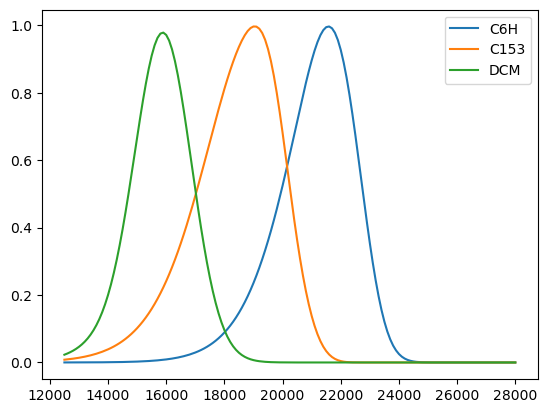

In [9]:
wnm = np.arange(12500, 28001, 100)

plt.figure()
for dye in default_ref_spectra.keys():
    plt.plot(wnm, ref_spec_wn(wnm, dye), label=dye)
plt.legend()

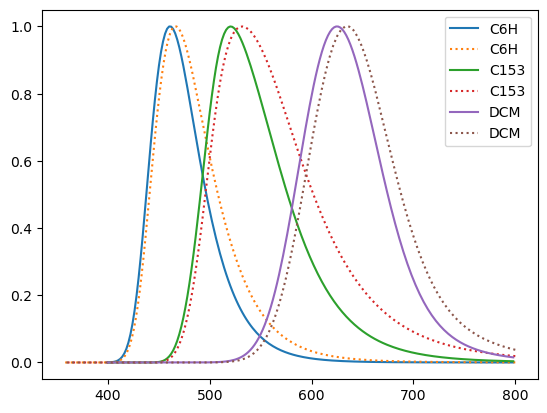

In [17]:
wnm = np.arange(12500, 28001, 100)
wl = np.arange(400, 800, 2)

plt.figure()
for dye in default_ref_spectra.keys():
    plt.plot(wl, rescale(ref_spec_wl(wl, dye)), label=dye)
    plt.plot(cmi2nm(wnm), rescale(ref_spec_wn(wnm, dye)*cmi2nm(wnm)**2), ":", label=dye)
plt.legend()

In [11]:
wnm = np.arange(12500, 28001, 100)

arr = []
plt.figure()
for i, p in enumerate(default_ref_spectra["BBOT"]):
    y = lognorm(wnm, *p)
    arr.append(y)
    plt.plot(wnm, y, label=i)
plt.legend()
arr = np.array(arr)

KeyError: 'BBOT'

<Figure size 640x480 with 0 Axes>

In [ ]:
arr.shape

In [ ]:
np.any(np.isnan(arr), axis=1)

In [ ]:
x = np.linspace(-1, 1, 1000)
np.log1p(x)

In [ ]:
x